# 1. Load csv and packages

In [2]:
import pandas as pd

# 2. Info/ Statistics Dataset

In [3]:
#read
df=pd.read_csv("insurance_claims.csv", parse_dates=["policy_bind_date", "incident_date"], index_col="policy_number")

#check duplicates
df.duplicated().sum() 
df['authorities_contacted']=df['authorities_contacted'].fillna("Police")

#ensure consistency on column names
rename ={'capital-gains':'capital_gains','capital-loss': 'capital_loss'}
df.rename(columns=rename, inplace=True)



## 3. Missing Values 
- remove NaNs in target
- remove NaNs if more than x in a row

In [4]:
# drop column as 100% nan-values
# drop umbrella limits as 80% of values are zeros, std = 1.1 Mio
df.drop(['months_as_customer',  'umbrella_limit',  'total_claim_amount', '_c39'],axis=1,inplace= True)

In [5]:
df.isna().sum().sum()

np.int64(0)

In [6]:
# #Type df.drop stuff
# for col in df.columns:
#     print(f"df.drop('{col}',axis=1,inplace=True)")

In [7]:
df.drop('age',axis=1,inplace=True)
df.drop('policy_bind_date',axis=1,inplace=True)
df.drop('policy_state',axis=1,inplace=True)
df.drop('policy_csl',axis=1,inplace=True)
df.drop('policy_deductable',axis=1,inplace=True)
df.drop('policy_annual_premium',axis=1,inplace=True)
df.drop('insured_zip',axis=1,inplace=True)
df.drop('insured_sex',axis=1,inplace=True)
df.drop('insured_education_level',axis=1,inplace=True)
df.drop('insured_occupation',axis=1,inplace=True)
df.drop('insured_relationship',axis=1,inplace=True)
df.drop('capital_gains',axis=1,inplace=True)
df.drop('capital_loss',axis=1,inplace=True)
df.drop('incident_date',axis=1,inplace=True)
df.drop('incident_city',axis=1,inplace=True)
df.drop('incident_location',axis=1,inplace=True)
df.drop('incident_hour_of_the_day',axis=1,inplace=True)
df.drop('number_of_vehicles_involved',axis=1,inplace=True)
df.drop('property_damage',axis=1,inplace=True)
df.drop('bodily_injuries',axis=1,inplace=True)
df.drop('witnesses',axis=1,inplace=True)
df.drop('police_report_available',axis=1,inplace=True)
# df.drop('injury_claim',axis=1,inplace=True)
# df.drop('property_claim',axis=1,inplace=True)
# df.drop('vehicle_claim',axis=1,inplace=True)
df.drop('auto_make',axis=1,inplace=True)
df.drop('auto_model',axis=1,inplace=True)
df.drop('auto_year',axis=1,inplace=True)

In [8]:
df.columns

Index(['insured_hobbies', 'incident_type', 'collision_type',
       'incident_severity', 'authorities_contacted', 'incident_state',
       'injury_claim', 'property_claim', 'vehicle_claim', 'fraud_reported'],
      dtype='object')

In [9]:
from sklearn.preprocessing import LabelEncoder
LabelEnc = LabelEncoder()
df['fraud_reported'] = LabelEnc.fit_transform(df['fraud_reported'])

## 4./5.  Train Test Split  and X,y Separation

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('fraud_reported', axis=1), df['fraud_reported'], test_size=0.2, random_state=42)


# 6. Replace missing numeric values with mean/median

In [11]:
# none

# 7. Replace missing categorical variables with mode

In [14]:
#Rename Strings
X_train["collision_type"]=X_train["collision_type"].apply(lambda x: "No Collision" if str(x)=="?" else x)
#X_train["police_report_available"]=X_train["police_report_available"].apply(lambda x: "Unknown" if str(x)=="?" else x)
#X_train["property_damage"]=X_train["property_damage"].apply(lambda x: "Unknown" if str(x)=="?" else x)

#test set
X_test["collision_type"]=X_test["collision_type"].apply(lambda x: "No Collision" if str(x)=="?" else x)
#X_test["police_report_available"]=X_test["police_report_available"].apply(lambda x: "Unknown" if str(x)=="?" else x)
#X_test["property_damage"]=X_test["property_damage"].apply(lambda x: "Unknown" if str(x)=="?" else x)

## 8. Encoding text variables

In [15]:
from sklearn.preprocessing import OneHotEncoder

enc=OneHotEncoder(handle_unknown='ignore')
X_train_enc=enc.fit_transform(X_train[['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state']]).toarray()
#dataframe
X_train_enc=pd.DataFrame(X_train_enc, columns=enc.get_feature_names_out(['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state']))

#reset index
X_train_enc.reset_index(drop=True, inplace=True)
X_train.reset_index(drop=True, inplace=True)

#concatenate
X_train=pd.concat([X_train, X_train_enc], axis=1)

#drop columns
X_train.drop(['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state'], axis=1, inplace=True)

# same for test data
X_test_enc=enc.transform(X_test[['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state']]).toarray()
X_test_enc=pd.DataFrame(X_test_enc, columns=enc.get_feature_names_out(['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state']))
X_test_enc.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
X_test=pd.concat([X_test, X_test_enc], axis=1)
X_test.drop(['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state'], axis=1, inplace=True)

# 9. Feature Scaling

In [16]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

minmax_scaler = MinMaxScaler()
rbst_scaler = RobustScaler()

minmax_col = [ "injury_claim",'vehicle_claim']
rbst_col = ['property_claim']


for column in minmax_col:
    X_train[column] = minmax_scaler.fit_transform(X_train[[column]])
    X_test[column] = minmax_scaler.fit_transform(X_test[[column]])
    
for column in rbst_col:
    X_train[column] = rbst_scaler.fit_transform(X_train[[column]])
    X_test[column] = rbst_scaler.transform(X_test[[column]])

# 10. Save sets as csv (train and test set)

In [17]:
df.to_csv('insurance_claims_clean.csv')
X_train.to_csv("X_train_1.csv")
X_test.to_csv("X_test_1.csv")

In [18]:
X_train

,injury_claim,property_claim,vehicle_claim,insured_hobbies_base-jumping,insured_hobbies_basketball,insured_hobbies_board-games,insured_hobbies_bungie-jumping,insured_hobbies_camping,insured_hobbies_chess,insured_hobbies_cross-fit,...,authorities_contacted_Fire,authorities_contacted_Other,authorities_contacted_Police,incident_state_NC,incident_state_NY,incident_state_OH,incident_state_PA,incident_state_SC,incident_state_VA,incident_state_WV
0,0.657343,1.165801,0.797333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.305361,-0.040751,0.493521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.013986,-1.039553,0.025538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.040093,-0.950060,0.042395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.994406,0.048742,0.714681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0.310023,2.100679,0.668386,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
796,0.795338,0.275669,0.750283,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
797,0.498834,0.622453,0.470248,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
798,0.342191,0.085497,0.737829,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [19]:
X_test

,injury_claim,property_claim,vehicle_claim,insured_hobbies_base-jumping,insured_hobbies_basketball,insured_hobbies_board-games,insured_hobbies_bungie-jumping,insured_hobbies_camping,insured_hobbies_chess,insured_hobbies_cross-fit,...,authorities_contacted_Fire,authorities_contacted_Other,authorities_contacted_Police,incident_state_NC,incident_state_NY,incident_state_OH,incident_state_PA,incident_state_SC,incident_state_VA,incident_state_WV
0,0.842271,1.472633,0.735795,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.277603,-0.243708,0.548701,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.710831,-0.007191,0.617424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.330179,0.919696,0.571970,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.032597,-0.889333,0.044372,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.413249,0.168598,0.349432,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
196,0.049422,-0.937275,0.028139,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
197,0.380126,1.223332,0.564123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
198,0.348580,1.031562,0.784497,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# 11.  Modelling

## Simple models
- Log Reg
- Decision Tree
- RFC

In [24]:
from sklearn.linear_model import LogisticRegression
# We'll consider the Logistic regression model as a baseline because it is fast to train and easy to evaluate. 
# The dataset has very few outliers thus the training should go well.

from sklearn.tree import DecisionTreeClassifier
# The Decision Tree model is also very fast to train
# Tree models are robust to outliers

from sklearn.ensemble import RandomForestClassifier
# The RandomForestClassifier model is more powerful but requires more fine-tuning to extract the best
# performance. It is robust to outliers and given the size of our dataset, it will not be a very long model to evaluate.

from sklearn.metrics import classification_report



In [29]:
# logistic regression
logistic = LogisticRegression()
logistic.fit(X_train, y_train)
logistic.score(X_test, y_test)
#classification report

y_pred_log = logistic.predict(X_test)
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       145
           1       0.65      0.65      0.65        55

    accuracy                           0.81       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.81      0.81      0.81       200



In [26]:
#decision tree
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
tree.score(X_test, y_test)
y_pred_tree = tree.predict(X_test)
#classification report
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83       145
           1       0.54      0.51      0.52        55

    accuracy                           0.74       200
   macro avg       0.68      0.67      0.67       200
weighted avg       0.74      0.74      0.74       200



In [27]:
##random forest
forest = RandomForestClassifier()
forest.fit(X_train, y_train)
forest.score(X_test, y_test)
y_pred_forest = forest.predict(X_test)
#classification report
print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86       145
           1       0.65      0.60      0.62        55

    accuracy                           0.80       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.80      0.80      0.80       200



In [30]:
# best F1 score in target=1 is logistic regression with 0.65
crosstab = pd.crosstab(y_test, y_pred_log, rownames=['Actual'], colnames=['Predicted'])
print(crosstab)

Predicted    0   1
Actual            
0          126  19
1           19  36


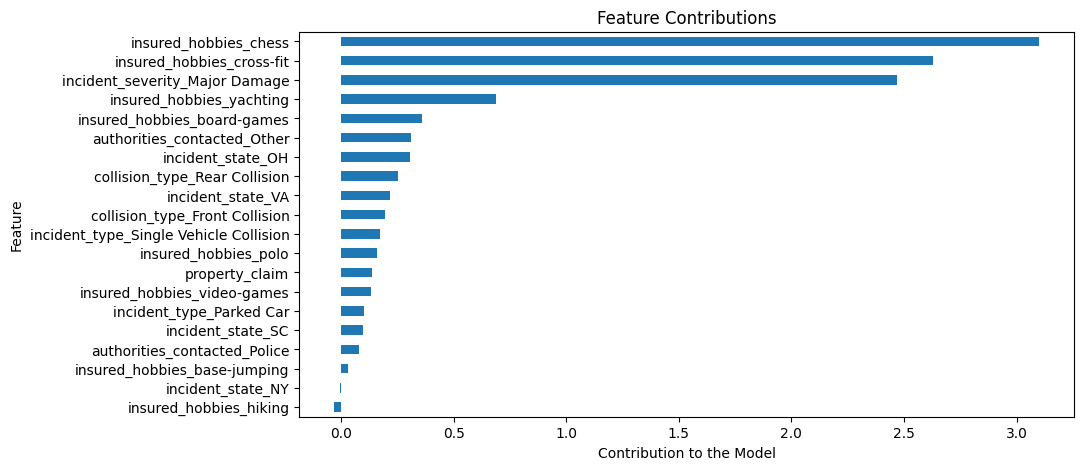

In [42]:
# Feature importance logistic regression
feature_contributions = logistic.coef_
feature_contributions = pd.DataFrame(feature_contributions, columns=X_train.columns)
feature_contributions.T.sort_values(by=0, ascending=False)
#plot, with top 20 features, descending
feature_contributions.T.sort_values(by=0, ascending=False).head(20).plot(kind='barh', title='Feature Importance', legend=False, figsize=(10,5))
plt.xlabel('Contribution to the Model')
plt.ylabel('Feature')
plt.title('Feature Contributions')
plt.gca().invert_yaxis()  # Place the most contributing features at the top
plt.show();

# 12. Hyperparameter Optimization

#### GridsearchCV

In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
#grid search for logistic regression
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)
#classification report
y_pred_grid = grid_search.predict(X_test)
print(classification_report(y_test, y_pred_grid))

{'C': 100}
0.85375
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       145
           1       0.68      0.73      0.70        55

    accuracy                           0.83       200
   macro avg       0.79      0.80      0.79       200
weighted avg       0.83      0.83      0.83       200



In [47]:
# better predicttion for target=1 with logistic regression
crosstab = pd.crosstab(y_test, y_pred_grid, rownames=['Actual'], colnames=['Predicted'])
print(crosstab)

Predicted    0   1
Actual            
0          126  19
1           19  36


# 14. Crossvalidation 

In [54]:
# crossvalidation for logistic regression
from sklearn.model_selection import cross_val_score
cross_val_score(LogisticRegression(), X_train, y_train, cv=5, scoring='f1')


array([0.57142857, 0.6835443 , 0.65789474, 0.72      , 0.65714286])

# 13. Resampling Techniques

In [55]:
# resampling
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
logistic_resampled = LogisticRegression()
logistic_resampled.fit(X_train_resampled, y_train_resampled)
y_pred_resampled = logistic_resampled.predict(X_test)
print(classification_report(y_test, y_pred_resampled))

              precision    recall  f1-score   support

           0       0.95      0.83      0.89       145
           1       0.67      0.87      0.76        55

    accuracy                           0.84       200
   macro avg       0.81      0.85      0.82       200
weighted avg       0.87      0.84      0.85       200



In [65]:
#resample RandomUnderSampler
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)
logistic_resampled = LogisticRegression()
logistic_resampled.fit(X_train_resampled, y_train_resampled)
y_pred_resampled = logistic_resampled.predict(X_test)
print(classification_report(y_test, y_pred_resampled))


              precision    recall  f1-score   support

           0       0.94      0.82      0.88       145
           1       0.65      0.87      0.74        55

    accuracy                           0.83       200
   macro avg       0.80      0.85      0.81       200
weighted avg       0.86      0.83      0.84       200



In [66]:
#resample RandomOverSampler
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler()
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)
logistic_resampled = LogisticRegression()
logistic_resampled.fit(X_train_resampled, y_train_resampled)
y_pred_resampled = logistic_resampled.predict(X_test)
print(classification_report(y_test, y_pred_resampled))  

              precision    recall  f1-score   support

           0       0.94      0.83      0.88       145
           1       0.66      0.87      0.75        55

    accuracy                           0.84       200
   macro avg       0.80      0.85      0.82       200
weighted avg       0.87      0.84      0.85       200

